In [31]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
iris_data = load_iris()
x_val = iris_data.data
y_val = iris_data.target
# print(x_val)
# print(y_val)
iris_df = pd.DataFrame(x_val, columns = iris_data.feature_names)
iris_df['species'] = iris_data.target_names[y_val]
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


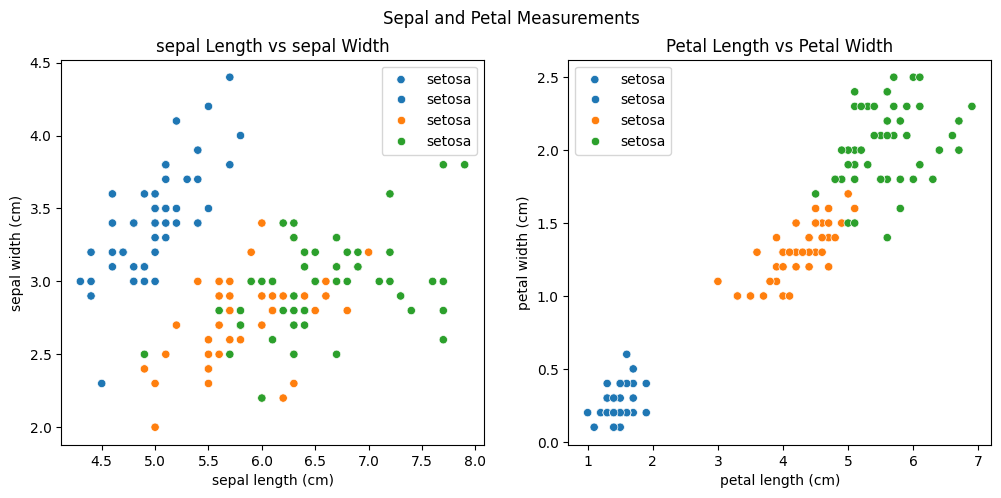

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data = iris_df, x = 'sepal length (cm)', y = 'sepal width (cm)', hue = 'species', ax = axes[0])
sns.scatterplot(data = iris_df, x = 'petal length (cm)', y = 'petal width (cm)', hue = 'species', ax = axes[1])
axes[0].legend(labels = iris_data.target_names[y_val])
axes[1].legend(labels = iris_data.target_names[y_val])
axes[0].set_title("sepal Length vs sepal Width")
axes[1].set_title("Petal Length vs Petal Width")
plt.suptitle("Sepal and Petal Measurements")
# plt.title("sepal, petal lengths vs sepal, petal widths")
plt.show()

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(x_val, y_val, test_size = 0.25, random_state = 42)
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, Y_train)
Y_predict = model.predict(X_test)
print("accuracy score in % is",round(accuracy_score(Y_test, Y_predict)*100, 2), "%")
print("precision score in % is", round(precision_score(Y_test, Y_predict, average = 'weighted')*100, 2), "%")
print("confusion matrix", confusion_matrix(Y_test, Y_predict))
print("recall score in % is",round(recall_score(Y_test, Y_predict, average = 'macro')*100,2), "%")
print(classification_report(Y_test, Y_predict, target_names = ['setosa', 'versicolor', 'virginica']))

accuracy score in % is 100.0 %
precision score in % is 100.0 %
confusion matrix [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
recall score in % is 100.0 %
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

